In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ripple_detection import Kay_ripple_detector
from ethograph.gui.plots_ephystrace import GenericEphysLoader, get_loader
from ripple_detection.core import ripple_bandpass_filter
from scipy.signal import filtfilt
from ethograph.features.energy import lowpass_envelope
from scipy.signal import decimate


from pathlib import Path

# -----------------------
# Paths & metadata
# -----------------------
params_path = Path(r"C:\Users\aksel\Desktop\Poppy sleep\ses-000_date-20260313_01\ephys\Poppy_260313_112716\kilosort4\params.py")
accel_path = Path(r"C:\Users\aksel\Desktop\Poppy sleep\ses-000_date-20260313_01\ephys\Poppy_260313_112716\info.rhd")

namespace = {}
exec(params_path.read_text(), namespace)
sr = namespace.get("sample_rate")         # ephys sample rate
dtype = namespace.get("dtype")
n_channels = namespace.get("n_channels_dat")
dat_path = namespace.get("dat_path")

# Loaders
loader = GenericEphysLoader(path=dat_path, n_channels=n_channels, dtype=dtype, sampling_rate=sr)
loader_accel = get_loader(accel_path, "1")  # accelerometer channel(s)

# -----------------------
# Parameters
# -----------------------
chunk_size = 100_000       # (30kHz -> ~3s windows, adjust as needed)
accelerometer_threshold = 0.25
zscore_thresh = 3.0
filter_num, filter_denom = ripple_bandpass_filter(sr)
target_fs = 1000  # Hz (standard for ripple detection)
q = int(sr / target_fs)

# -----------------------
# Compute animal speed from accelerometer
# -----------------------

# -----------------------
# Iterate over chunks
# -----------------------
n_samples = len(loader)
all_ripples = []

start = 88406220

In [27]:
from scipy.signal import decimate, filtfilt


all_ripples = []

for start in range(0, n_samples, chunk_size):
    end = min(start + chunk_size, n_samples)

    chunk = loader[start:end]
    accel_chunk = loader_accel[start:end]

    # Downsample
    chunk_ds = decimate(chunk, q, axis=0)
    accel_ds = decimate(accel_chunk, q, axis=0)


    accel_norm = np.linalg.norm(accel_ds, axis=1)
    speed_chunk = np.abs(accel_norm - np.mean(accel_norm))
    
    # plt.figure(figsize=(12, 4))
    # plt.plot(speed_chunk)
    # plt.show()


    t = (np.arange(len(chunk_ds)) / target_fs) + (start / sr)


    for ch in range(chunk_ds.shape[1]):

        filtered_lfp = filtfilt(
            filter_num, filter_denom,
            chunk_ds[:, ch],
            axis=0
        )

        ripples_ch = Kay_ripple_detector(
            t,
            filtered_lfp[:, np.newaxis],
            speed_chunk,
            sampling_frequency=target_fs,
            speed_threshold=accelerometer_threshold,
            zscore_threshold=zscore_thresh
        )


        # Store results PER CHANNEL
        if not ripples_ch.empty:
            ripples_ch["channel"] = ch
            all_ripples.append(ripples_ch)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import filtfilt

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import filtfilt, decimate, hilbert

def plot_ripples_with_accel(
    loader,
    loader_accel,
    all_ripples,
    ch=0,
    t0=10,
    t1=12,
    sr=30000,
    target_fs=1000,
    q=30,
    filter_num=None,
    filter_denom=None,
):

    # -----------------------
    # Load raw data
    # -----------------------
    start_idx = int(t0 * sr)
    end_idx = int(t1 * sr)

    chunk = loader[start_idx:end_idx]
    raw = chunk[:, ch]

    accel_chunk = loader_accel[start_idx:end_idx]

    # -----------------------
    # Downsample
    # -----------------------
    lfp_ds = decimate(raw, q, axis=0)
    accel_ds = decimate(accel_chunk, q, axis=0)

    # -----------------------
    # Filter LFP
    # -----------------------
    lfp_filt = filtfilt(filter_num, filter_denom, lfp_ds)

    # -----------------------
    # Hilbert envelope
    # -----------------------
    envelope = np.abs(hilbert(lfp_filt))

    # Normalize envelope for visualization
    envelope = envelope / np.max(envelope) * np.max(np.abs(lfp_filt))

    # -----------------------
    # Speed
    # -----------------------
    accel_norm = np.linalg.norm(accel_ds, axis=1)
    speed = np.abs(accel_norm - np.mean(accel_norm))

    # -----------------------
    # Time axis
    # -----------------------
    t = np.arange(len(lfp_filt)) / target_fs + t0

    # -----------------------
    # Get ripples
    # -----------------------
    ripples_ch = [
        df for df in all_ripples
        if not df.empty and df["channel"].iloc[0] == ch
    ]

    # -----------------------
    # Plot
    # -----------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 6), sharex=True,
        gridspec_kw={"height_ratios": [1, 2]}
    )

    # ---- Speed ----
    ax1.plot(t, speed, lw=1)
    ax1.axhline(accelerometer_threshold, linestyle="--")
    ax1.set_ylabel("Speed (a.u.)")
    ax1.set_title(f"Channel {ch} Ripple Detection")

    # ---- LFP ----
    ax2.plot(t, lfp_filt, lw=1, label="LFP")

    # Hilbert envelope
    ax2.plot(t, envelope, alpha=0.7, label="Envelope")

    # ---- Ripples ----
    for df in ripples_ch:
        for _, row in df.iterrows():

            if row["end_time"] < t0 or row["start_time"] > t1:
                continue

            ax2.axvspan(
                row["start_time"],
                row["end_time"],
                alpha=0.3
            )

    ax2.set_ylabel("Filtered LFP")
    ax2.set_xlabel("Time (s)")
    ax2.set_xlim(t0, t1)

    ax2.legend()

    plt.tight_layout()
    plt.show()
    
    
for t0 in np.arange(0, 100, 1):
    t1 = t0 + 1
    plot_ripples_with_accel(
        loader,
        loader_accel,
        all_ripples,
        ch=5,
        t0=t0,
        t1=t1,
        sr=sr,
        target_fs=target_fs,
        q=q,
        filter_num=filter_num,
        filter_denom=filter_denom
    )

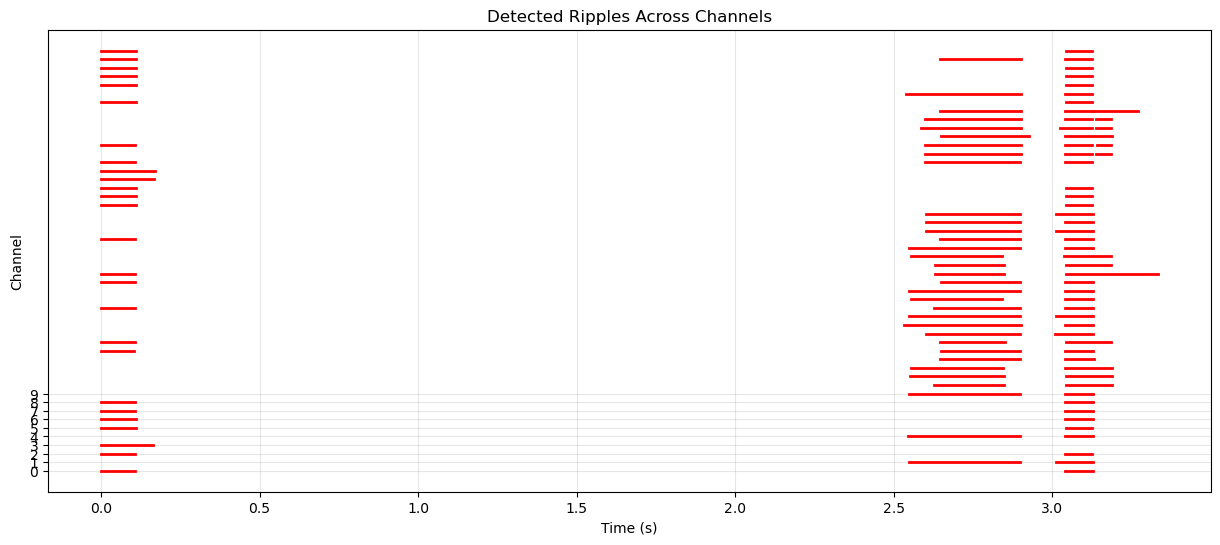

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot signal
plt.plot(t, lfp_filt, color="black", lw=1)

# Overlay ripples
for df in ripples_ch:
    for _, row in df.iterrows():

        # only plot ripples inside window
        if row["end_time"] < t0 or row["start_time"] > t1:
            continue

        plt.axvspan(
            row["start_time"],
            row["end_time"],
            color="red",
            alpha=0.3
        )

plt.xlabel("Time (s)")
plt.ylabel("LFP (filtered)")
plt.title(f"Channel {ch} Ripple Detection")
plt.xlim(t0, t1)

plt.show()

In [ ]:







# Your data
time = np.arange(0, 10, 0.001)  # 10 seconds at 1000 Hz
LFPs = np.random.randn(len(time), 4)  # 4 channels of LFP data
speed = np.abs(np.random.randn(len(time)))  # Animal speed
sampling_frequency = 1000  # Hz

# Detect ripples
ripple_times = Kay_ripple_detector(
    time, LFPs, speed, sampling_frequency,
    speed_threshold=4.0,        # cm/s
    minimum_duration=0.015,     # seconds
    zscore_threshold=2.0
)

print(ripple_times)